In [1]:
%matplotlib widget

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors
import random

# Find Ill-posedness of an inversion problem

In [11]:
# Create a large range of models

# Define EC of first layer in mS/m
sigma_1 = np.logspace(2,3, 1000)

# EC of second layer with constant ratios
sigma_2 = sigma_1 / 10

# Define a constant product of sigma_1 * thick_1
product_s1t1 = 500

# Define thickness of first layer in meters
thick_1 = product_s1t1 / sigma_1

# Create the models array (EC in S/m)

models =list(np.array([ thick_1, sigma_1/1000, sigma_2/1000]).T)


# Forward Function

In [12]:
def FDEM(sigmas, thicks, coil_orient=np.array(['H', 'P', 'V']), height=0.15):

    Freq = 9000
    coil_spacing = [2, 4, 8]
    coil_spacing_p = [2.1, 4.1, 8.2]
    
    res_air = 1e6 # air resistivity
    
    sigmas = np.array(sigmas)
    res = np.hstack(([res_air], 1/sigmas))
    
   # print('res: ', res)
    
    depth = np.hstack(([0],-np.cumsum(thicks)))
    
   # print('depth:', depth)
    
    # Define source and receivers geometry
    
    source = [0, 0, -height]
    receivers = [coil_spacing, np.zeros_like(coil_spacing), -height]
    receivers_p = [coil_spacing_p, np.zeros_like(coil_spacing_p), -height]
    
    # Define resistivity model
    #res = np.hstack((res_air, res)) # include air resistivity
    
    # Empty array to store store responses
    OUT = []
    
    # Calculate for horizontal coil orientation
    if any(coil_orient == 'H'):
        # Secondary magnetic field
        H_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        H_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                              ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (H_Hs/H_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for vertical coil orientation
    if any(coil_orient == 'V'):
        # Secondary magnetic field
        V_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 55, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        V_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq, ab = 55, 
                              verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (V_Hs/V_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for perpendicular coil orientation
    if any(coil_orient == 'P'):
        P_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 46, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime= Freq,
                              ab = 66, verb = 0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (P_Hs/P_Hp).real.amp() * 1e3 # In Phase

        OUT.append([op, ip])

    return np.array(OUT).ravel()

# Forward modelling class

In [13]:
class FDEM_1D(pg.frameworks.Modelling):
    """ Class to Initialize the model for Gauss-Newton inversion
    using the quadrature (Q) and in-phase (IP) components of the measurements
    for a n-layered model
    
    Input:

        nlay : number of layers
    """   
    def __init__(self, nlay=3):
        self.nlay = nlay
        mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(mesh)

    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
      #  print('model:', par)  
        resp = FDEM(sigmas = par[self.nlay-1:],
                           thicks = par[:self.nlay-1]
                              )
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
        
    def drawModel(self, ax, model):
        pg.viewer.mpl.drawModel1D(ax = ax,
                                  model = model,
                                  plot = 'semilogx',
                                  xlabel = 'Electrical conductivity (S/m)',
                                  )
        ax.set_ylabel('Depth in (m)')

# Define random starting models

In [18]:
model_start_1 = random.sample(models, k=1)[0]
model_start_1

array([0.97557417, 0.51251869, 0.05125187])

In [19]:
model_true_1 = random.sample(models, k=1)[0]
model_true_1

array([0.67158059, 0.74451229, 0.07445123])

# Run Inversion

In [20]:
# Inversion for 2 Layers

FOP = FDEM_1D(nlay = 2)

data = FOP.response(model_true_1)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(1/1000,1000/1000)

FOP.region(0).setTransModel(transThk)
FOP.region(1).setTransModel(transSig)

inv = pg.Inversion()
inv.setForwardOperator(FOP)
J = inv.fop.jacobian()

rel_err = np.ones_like(data)*1e-1
model_inv = inv.run(data, rel_err, verbose=True, startModel=model_start_1, lam=0, )

05/03/25 - 11:51:58 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 0.0268541/14.9562
fop: <__main__.FDEM_1D object at 0x7fba0ea653f0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x7fba05f77df0>
Model transformation (cumulative):
	 0 <pgcore._pygimli_.RTransLogLU object at 0x7fbe68ee2160>
	 1 <pgcore._pygimli_.RTransLogLU object at 0x7fbe68ecdad0>
min/max (data): 0.67/372
min/max (error): 10%/10%
min/max (start model): 0.05/0.98
--------------------------------------------------------------------------------
use model trans from RegionManager
min/max(dweight) = 0.0268541/14.9562
Building constraints matrix
constraint matrix of size(nBounds x nModel) 1 x 3
check Jacobian: wrong dimensions: (0x0) should be (18x3)  force: 1
jacobian size invalid, forced recalc: 1
inv.iter 0 ... chi² =    8.29
--------------------------------------------------------------------------------
inv.iter 1 ... Calculating Jacobian matrix (forced=1)...Create Jacobian matrix (brute force) ... ... 0.00795464 s.
... 0.0106949 s
min data = 0.668618 max 

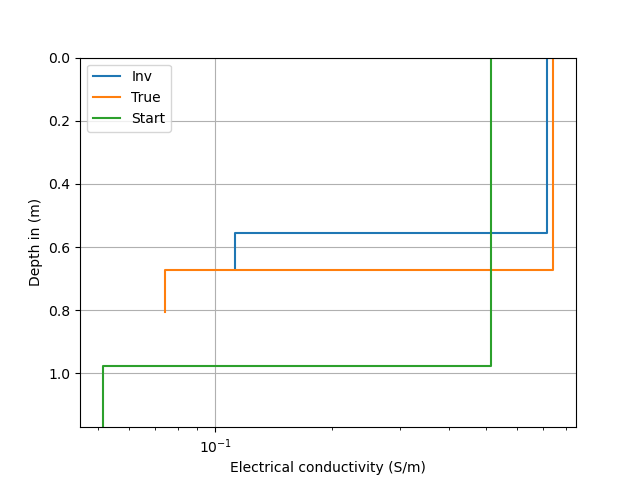

In [21]:
fig, ax = plt.subplots()

FOP.drawModel(ax, model_inv, )
FOP.drawModel(ax, model_true_1, )
FOP.drawModel(ax, model_start_1, )

ax.legend(['Inv', 'True', 'Start'])

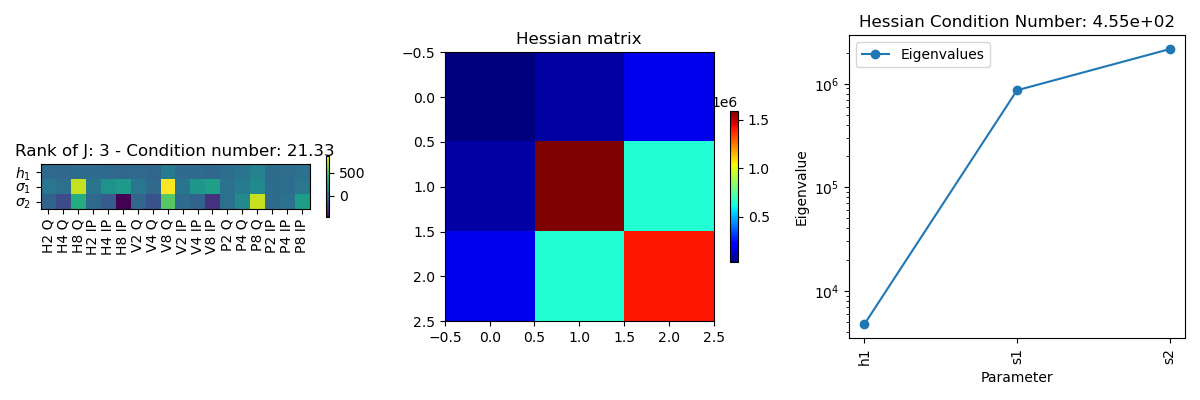

In [22]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

# Plot Jacobian
c = ax[0].imshow(np.array(J).T)
fig.colorbar(c, shrink=0.2, ax=ax[0])
xticks = ['H2 Q', 'H4 Q', 'H8 Q', 'H2 IP', 'H4 IP', 'H8 IP', 'V2 Q', 'V4 Q', 'V8 Q',
          'V2 IP', 'V4 IP', 'V8 IP', 'P2 Q', 'P4 Q', 'P8 Q', 'P2 IP', 'P4 IP', 'P8 IP' ]
yticks = ['$h_1$', '$\sigma_1$', '$\sigma_2$' ]
ax[0].set_xticks(range(len(data)), labels=xticks, rotation = 90)
ax[0].set_yticks(range(len(model_true_1)), labels=yticks)
ax[0].set_title('Rank of J: ' + str( np.linalg.matrix_rank(J)) +' - Condition number: %.2f' %np.linalg.cond(J) )

# Calculate Hessian
J = np.array(J)
JTJ = np.matmul(J.T,J)
# Plot Hessian
c = ax[1].imshow(JTJ, cmap='jet') 
fig.colorbar(c, ax=ax[1], shrink=0.5)
ax[1].set_title('Hessian matrix')

# Compute eigenvalues
eigenvalues, eigenvectors = LA.eigh(JTJ)  # More stable for symmetric matrices

# Plot eigenvalues

xticks = ['h1', 's1', 's2']

ax[2].set_xticks(range(3), labels=xticks, rotation = 90)
ax[2].semilogy(eigenvalues, 'o-', label="Eigenvalues")
#ax[2].axhline(y=0, color='r', linestyle='--', label="Zero Line")
ax[2].set_xlabel("Parameter")
ax[2].set_ylabel("Eigenvalue")
ax[2].legend()

# Print condition number
condition_number = np.max(eigenvalues) / np.min(eigenvalues)
ax[2].set_title(f"Hessian Condition Number: {condition_number:.2e}")

plt.tight_layout()

# Check with 10 different starting models

In [23]:
model_start_10 = random.sample(models, k=10)
model_start_10

[array([2.30480224, 0.21693835, 0.02169384]),
 array([0.92307347, 0.54166869, 0.05416687]),
 array([0.55720763, 0.89733158, 0.08973316]),
 array([0.87138734, 0.57379764, 0.05737976]),
 array([4.15805208, 0.12024861, 0.01202486]),
 array([4.59127142, 0.1089023 , 0.01089023]),
 array([0.66849187, 0.74795225, 0.07479523]),
 array([4.2452076 , 0.11777987, 0.01177799]),
 array([1.88602125, 0.26510836, 0.02651084]),
 array([3.49796008, 0.14294045, 0.01429405])]

In [24]:
# Run inversions

J_s = []

for sm in model_start_10:
    # Inversion for 2 Layers

    FOP = FDEM_1D(nlay = 2)
    
    data = FOP.response(model_true_1)
    
    transThk = pg.trans.TransLogLU(0.1,5)
    transSig = pg.trans.TransLogLU(1/1000,1000/1000)
    
    FOP.region(0).setTransModel(transThk)
    FOP.region(1).setTransModel(transSig)
    
    inv = pg.Inversion()
    inv.setForwardOperator(FOP)
    J = inv.fop.jacobian()
    
    rel_err = np.ones_like(data)*1e-1
    model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
    J_s.append(np.array(J))

In [25]:
# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
        print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
        print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
        print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")


The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.


In [26]:
df = pd.DataFrame(data= np.array([np.array(model_start_10)[:,0], np.array(model_start_10)[:,1], np.array(model_start_10)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])


In [27]:
df.style.highlight_max(subset=pd.IndexSlice[:, ['cond']], color='green')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,2.304802,0.216938,0.021694,3.000000,17.827940,317.835431,1.000000
1,0.923073,0.541669,0.054167,3.000000,19.973371,398.935544,1.000000
2,0.557208,0.897332,0.089733,3.000000,11.812758,139.541254,1.000000
3,0.871387,0.573798,0.057380,3.000000,18.688442,349.257871,1.000000
4,4.158052,0.120249,0.012025,3.000000,176.657542,31207.887086,1.000000
5,4.591271,0.108902,0.010890,3.000000,1672.628564,2797686.312531,1.000000
6,0.668492,0.747952,0.074795,3.000000,14.094977,198.668370,1.000000
7,4.245208,0.117780,0.011778,3.000000,965.164454,931542.423720,1.000000
8,1.886021,0.265108,0.026511,3.000000,15.383266,236.644883,1.000000
9,3.497960,0.142940,0.014294,3.000000,19.598734,384.110364,1.000000


# Check with 100 different starting models

In [28]:
model_start_100 = random.sample(models, k=100)

# Run inversions

J_s = []

for sm in model_start_100:
    # Inversion for 2 Layers

    FOP = FDEM_1D(nlay = 2)
    
    data = FOP.response(model_true_1)
    
    transThk = pg.trans.TransLogLU(0.1,5)
    transSig = pg.trans.TransLogLU(1/1000,1000/1000)
    
    FOP.region(0).setTransModel(transThk)
    FOP.region(1).setTransModel(transSig)
    
    inv = pg.Inversion()
    inv.setForwardOperator(FOP)
    J = inv.fop.jacobian()
    
    rel_err = np.ones_like(data)*1e-1
    model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
    J_s.append(np.array(J))

# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
       # print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
       # print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
       # print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")






































































*** ################################################################## ./core/src/solver.cpp:148	






















































































































In [29]:
df = pd.DataFrame(data= np.array([np.array(model_start_100)[:,0], np.array(model_start_100)[:,1], np.array(model_start_100)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])

df.style.background_gradient(subset=pd.IndexSlice[:, ['rank_J', 'CN_J', 'CN_H','cond']])

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,1.450215,0.344776,0.034478,3.000000,15.171707,230.180703,1.000000
1,1.031061,0.484937,0.048494,3.000000,15.022323,225.670201,1.000000
2,1.125440,0.444271,0.044427,3.000000,17.442265,304.232620,1.000000
3,0.781923,0.639449,0.063945,3.000000,16.581663,274.951541,1.000000
4,1.242697,0.402351,0.040235,3.000000,14.166681,200.694855,1.000000
5,3.970726,0.125922,0.012592,3.000000,14.716431,216.573331,1.000000
6,1.796907,0.278256,0.027826,3.000000,15.786728,249.220784,1.000000
7,2.326150,0.214947,0.021495,3.000000,17.485289,305.735317,1.000000
8,0.751878,0.665002,0.066500,3.000000,15.904426,252.950781,1.000000
9,3.204622,0.156025,0.015602,3.000000,17.779404,316.107205,1.000000


In [30]:
df[df['cond']==0].style.highlight_min(subset=pd.IndexSlice[:, ['cond']], color='red')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond


# Check with 1000 starting models

In [31]:
# Run inversions

J_s = []
models_test = []

for sm in models:
    # Inversion for 2 Layers
    if (sm == model_true_1).any():
        pass
    else:
        models_test.append(sm)
        FOP = FDEM_1D(nlay = 2)
        
        data = FOP.response(model_true_1)
        
        transThk = pg.trans.TransLogLU(0.01,5.1)
        transSig = pg.trans.TransLogLU(1/1000,2000/1000)
        
        FOP.region(0).setTransModel(transThk)
        FOP.region(1).setTransModel(transSig)
        
        inv = pg.Inversion()
        inv.setForwardOperator(FOP)
        J = inv.fop.jacobian()
        
        rel_err = np.ones_like(data)*1e-1
        model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
        J_s.append(np.array(J))

# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
       # print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
       # print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
       # print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")


In [32]:
df = pd.DataFrame(data= np.array([np.array(models_test)[:,0], np.array(models_test)[:,1], np.array(models_test)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])

df.style.background_gradient(subset=pd.IndexSlice[:, ['rank_J', 'CN_J', 'CN_H','cond']])

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,5.000000,0.100000,0.010000,3.000000,246777.417951,60898912227.211060,1.000000
1,4.988489,0.100231,0.010023,3.000000,246428.827607,60727016602.364754,1.000000
2,4.977004,0.100462,0.010046,3.000000,241397.501627,58272897916.493210,1.000000
3,4.965546,0.100694,0.010069,3.000000,233491.065369,54518188029.629974,1.000000
4,4.954114,0.100926,0.010093,3.000000,210357.604752,44250365537.920540,1.000000
5,4.942709,0.101159,0.010116,3.000000,25176.445444,633853384.354506,1.000000
6,4.931329,0.101393,0.010139,3.000000,10475.105338,109727830.862555,1.000000
7,4.919976,0.101627,0.010163,3.000000,4678.821390,21891369.593763,1.000000
8,4.908649,0.101861,0.010186,3.000000,8325.866958,69320060.045491,1.000000
9,4.897348,0.102096,0.010210,3.000000,10179.152355,103615142.381872,1.000000


In [33]:
df[df['cond']==0].style.highlight_min(subset=pd.IndexSlice[:, ['cond']], color='red')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond


Text(0.5, 1.0, 'Condition Number of Hessian')

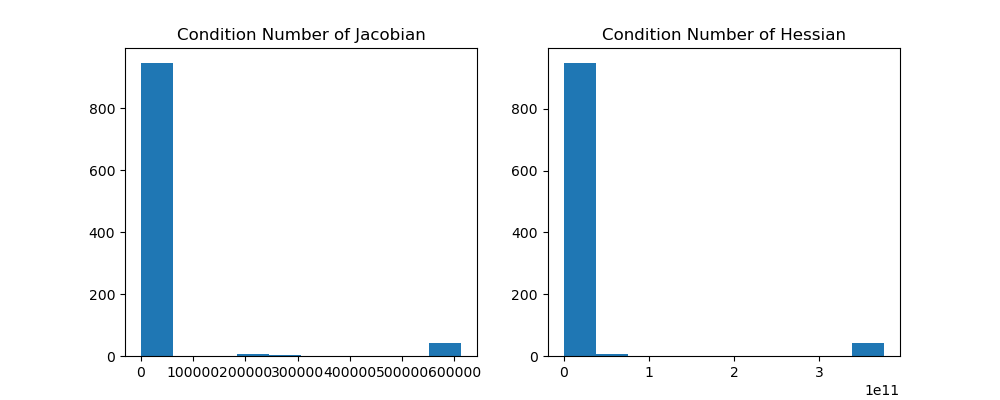

In [38]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].hist(df['CN_J'])
ax[0].set_title('Condition Number of Jacobian')

ax[1].hist(df['CN_H'])
ax[1].set_title('Condition Number of Hessian')